0314(금) 2주차 과제\
핸즈온 7장 앙상블 학습과 랜덤 포레스트 p.257-272

# 7.5 부스팅

**부스팅**
- 약한 학습기를 여러 개 연결해 강한 학습기를 만드는 앙상블 방법
- 앞의 모델을 보완해가며 일련의 예측기를 학습시킴
    - 에이다부스트
    -그레이디언트 부스팅

## 7.5.1 에이다부스트

**에이다부스트 방식**
- 이전 모델이 과소적합했던 훈련 샘플의 가중치를 더 높임

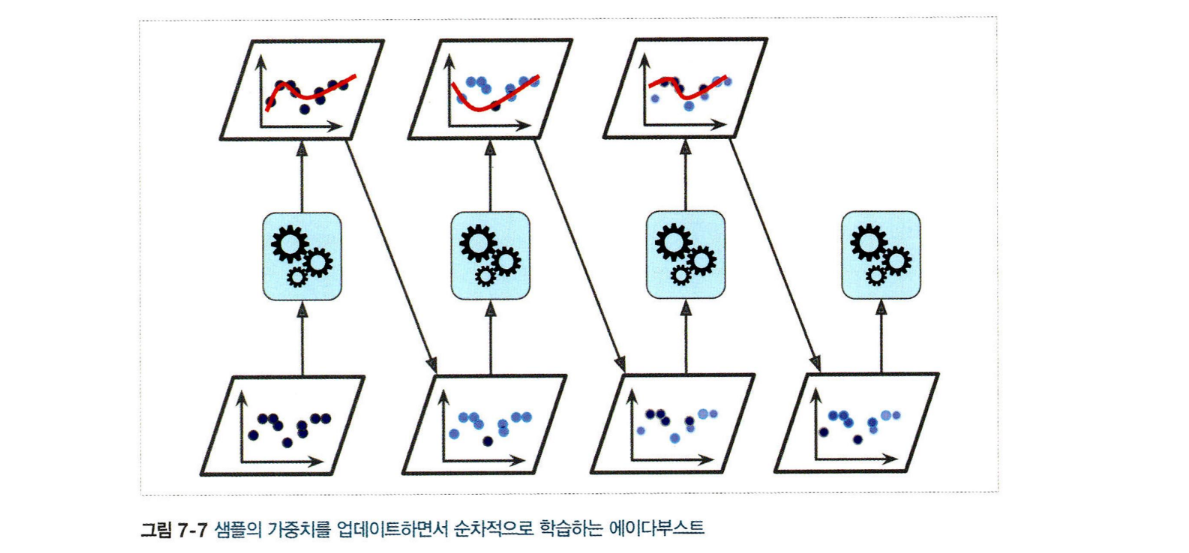

    ex.
    1. 결정 트리 등 알고리즘이 기반이 되는 첫 번째 분류기를 훈련 세트에서 훈련시키고 예측을 만듦
    2. 알고리즘이 잘못 분류된 훈련 샘플의 가중치를 상대적으로 높임.
    3. 두 번째 분류기는 업데이트된 가중치를 사용해 훈련 및 예측.
    4. 가중치 업데이트
    5. 반복

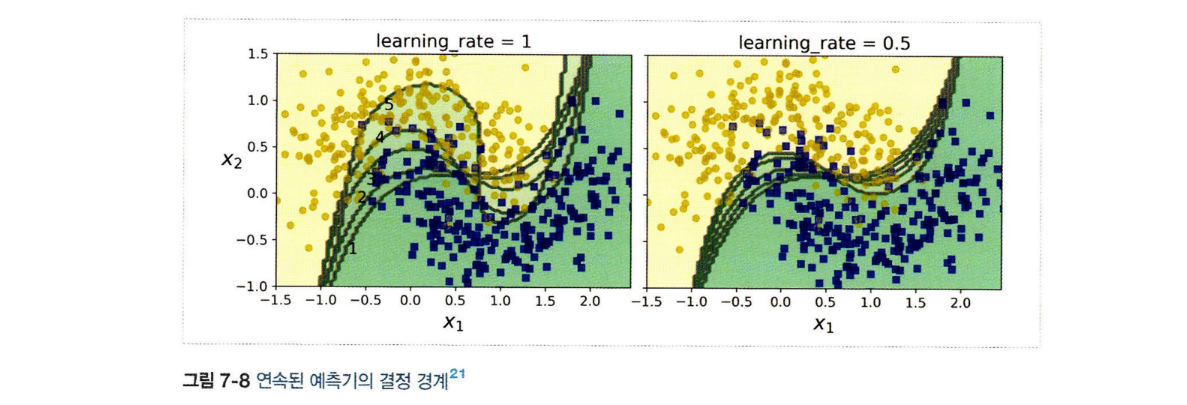

    - 규제를 강하게 한 RBF 커널 SVM 분류기

    - 첫 번째 분류기: 많은 샘플을 잘못 분류->이 샘플들의 가중치 증가
    - 두 번째 분류기: 이 샘플들을 더 정확히 예측
    - 오른쪽 그래프는 학습률만 반으로 낮춤(즉, 잘못 분류된 샘플의 가중치는 반복마다 절반 정도만 높아짐)

    -> 이런 연속된 학습 기법은 경사 하강법과 비슷함
        - 경사 하강법: 비용 함수 최소화를 위해 한 예측기의 모델 파라미터 조정
        - 에이다부스트: 더 좋아지도록 앙상블에 예측기 추가

**연속된 학습 기법의 단점**
- 각 에측기는 이전 예측기가 훈련, 평가된 후 학습될 수 있기 때문에 병렬화나 분할을 할 수 없음
- 결국 배깅, 페이스팅만큼 확장성이 높지 않음

**에이다부스트 알고리즘**
1. 각 샘플 가중치 $w^{(i)}$는 초기에 $\frac{1}{m}$로 초기화됨
2. 첫 번째 예측기가 학습되고, 가중치가 적용된 에러율 $r_1$이 훈련 세트에 대해 계산됨

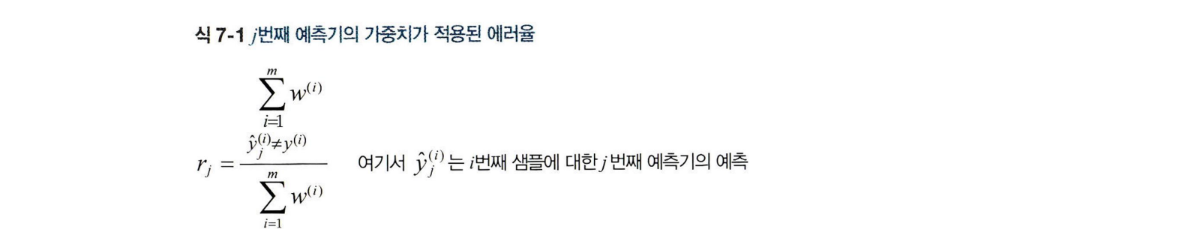

3. 예측기의 가중치 $\alpha_j$는 아래 식으로 계산됨
    - 여기서 $\eta$는 기본값이 1인 학습률 파라미터
    - 예측기가 정확할수록 가중치가 높아짐
    - 무작위면 0
    - 무작위보다 정확도가 낮으면 음수

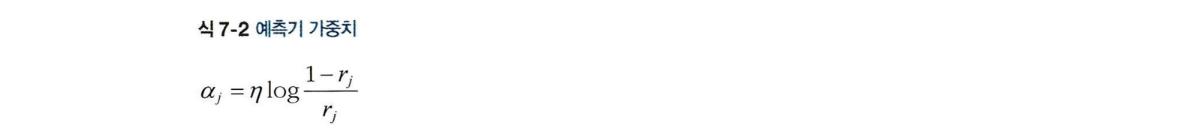

4. 에이다부스트의 알고리즘이 아래 식을 사용해 샘플의 가중치를 업데이트
    - 즉, 잘못 분류된 샘플의 가중치 증가

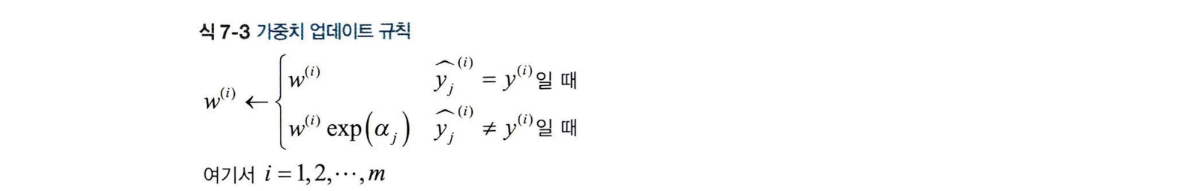

5. 모든 샘플의 가중치 정규화
 - 즉, $\sum_{i=1}^{m} w^{(i)}$ 으로 나눔

6. 새 예측기가 업데이트된 가중치를 사용해 훈련
7. 전체 과정 반복
8. 지정된 에측기 수에 도달하거나 완벽한 예측기가 만들어지면 중지

---

- 예측을 할 때 에이다부스트는 딘순히 모든 예측기의 예측을 계산하고 가중치를 더해 결과를 만듦
- 가중치 합이 가장 큰 클래스가 결과가 됨

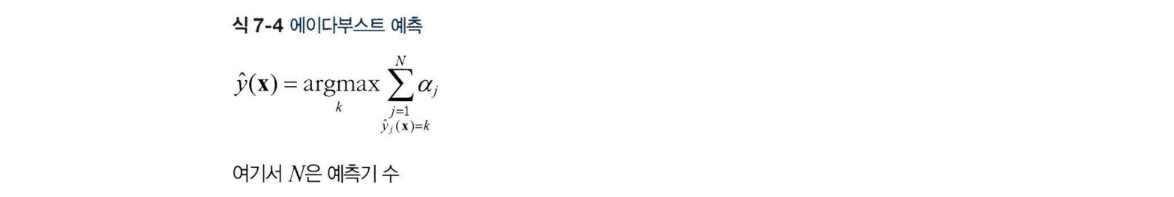

**SAMME와 SAMME.R**
- 사이킷런은 SAMME라는 에이다부스트의 다중 클래스 버전 사용
- 클래스가 두 개 뿐일 땐 SAMME가 에이다부스트와 동일
- 예측기가 클래스의 확률을 추정할 수 있다면 SAMME.R 이라는 변종 사용

In [1]:
import warnings
warnings.filterwarnings('ignore')

# import package
import numpy as np
import os

#5장에서 소개한 moons dataset 불러오기
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
X,y = make_moons(n_samples=100, noise=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [2]:
# AdaBoostClassifier 사용해 200개의 얕은 결정 트리 기반 훈련
# 결정 트리는 max_depth=1 (즉, 결정 노드 하나와 리프 노드 두 개로 이루어진 트리)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME", learning_rate=0.5
)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200)

**TIP**
- 에이다부스트 앙상블이 훈련 세트에 과대적합되면 추정기 수를 줄이거나 규제를 강하게 해볼 것

## 7.5.2 그레이디언트 부스팅

**그레이디언트 부스팅**
- 에이다부스트와 비슷한 점: 앙상블에 이전까지의 오차를 보정하도록 예측기를 순차적으로 추가함
- 에이다부스트와 다른 점: 반복마다 샘플의 가중치를 수정하는 대신 이전 예측기가 만든 **잔여 오차**에 새로운 예측기를 학습시킴

**그레이디언트 트리 부스팅 (그레이디언트 부스티드 회귀 트리 GBRT)**
- 결정 트리를 기반 예측기로 사용하는 간단한 회귀

In [3]:
# DecisionTreeRegressor를 훈련 세트에 학습
# 여기서 훈련 세트는 잡음이 섞인 2차 곡선 형태의 훈련 세트

from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X, y)

DecisionTreeRegressor(max_depth=2)

In [4]:
# 첫 번째 예측기에서 생긴 잔여 오차에 두 번째 DecisionTreeRegressor 훈련

y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X, y2)

DecisionTreeRegressor(max_depth=2)

In [5]:
# 두 번째 예측기에서 생긴 잔여 오차에 세 번째 DecisionTreeRegressor 훈련

y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2)

In [6]:
# 모든 트리의 예측을 더해서 새로운 샘플에 대한 예측 만들기

X_new = np.array([[0.8, 0.8]])
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))
y_pred

array([-0.02932729])

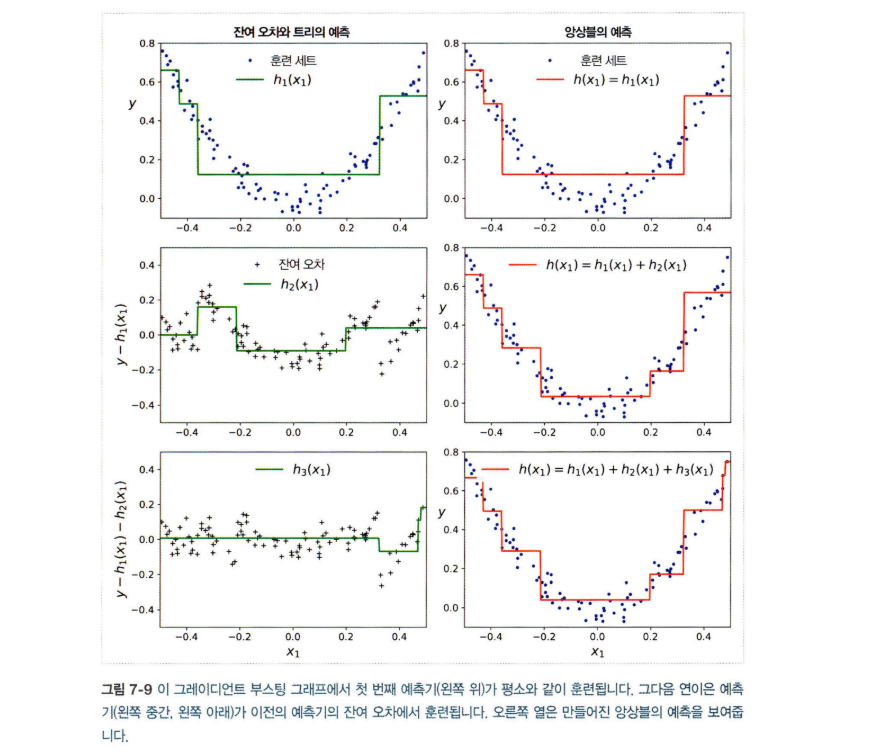

    - 왼쪽 열: 세 트리의 예측
    - 오른쪽 열: 앙상블의 예측

    - 트리가 앙상블에 추가될수록 앙상블의 예측이 좋아짐

In [7]:
# GradientBoostRegressor 사용 -> GBRT 앙상블 간단히 훈련

from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3)

**learning rate 매개변수**
- 각 트리의 기여 정도를 조절
 - **축소** : 낮게 설정(ex. 0.1)하면 앙상블을 훈련 세트에 학습시키기 위해 많은 트리가 필요함, 예측의 성능은 좋아짐

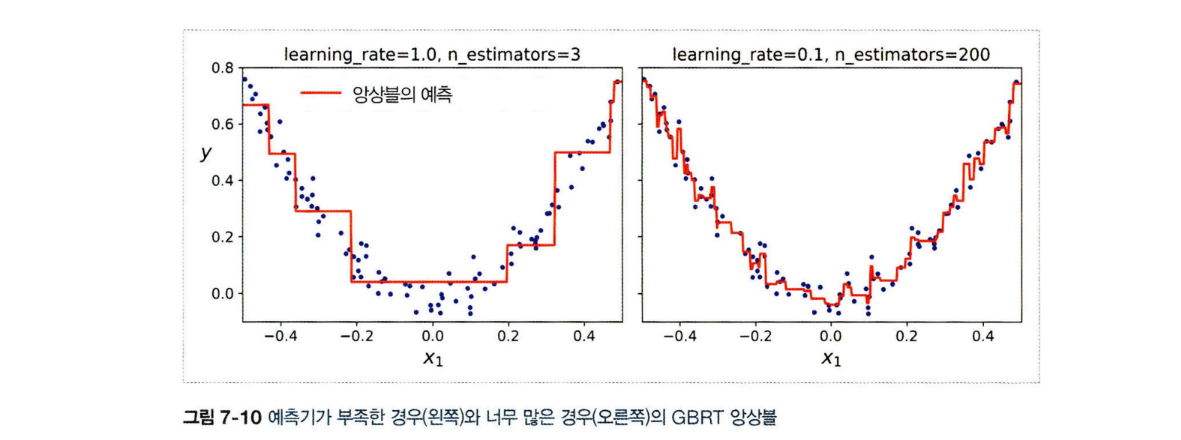

In [8]:
# 120개의 트리로 GBRT 앙상블을 훈련시키고 최적의 트리 수를 찾기 위해 각 훈련 단계에서 검증 오차 측정

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y)

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120)
gbrt.fit(X_train, y_train)

errors = [mean_squared_error(y_val, y_pred) for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=19)

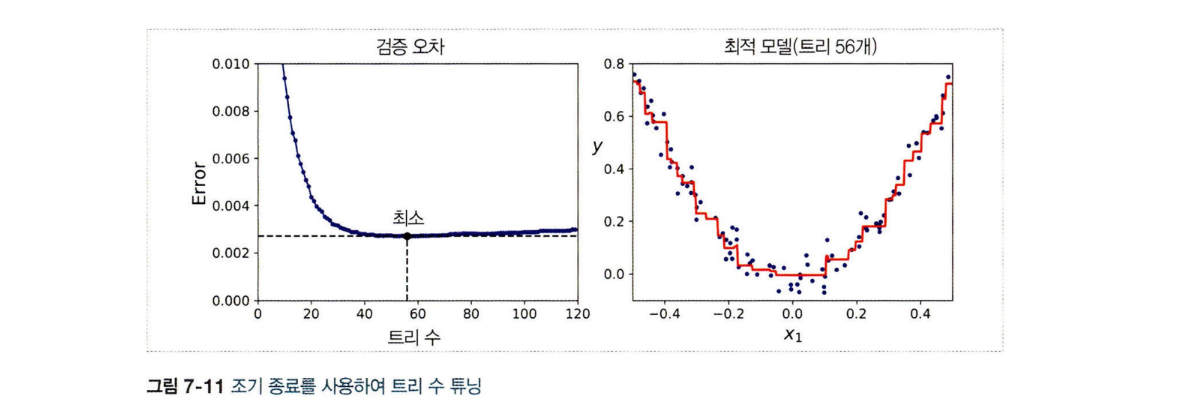

- 다수의 트리 훈련 후 최적의 수를 찾기 위해 살펴보는 대신, 실제로 훈련을 중지하는 방법으로 조기 종료를 구현할 수도 있음
    - warm_start=True: 사이킷런이 fit()메서드가 호출될 때 기존 트리를 유지하고 훈련을 후가할 수 있도록 해줌

In [9]:
# 연속 다섯번 반복동안 검증 오차가 향상되지 않으면 훈련을 멈춤

gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True)

min_val_error = float("inf")
error_going_up = 0
for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)
    y_pred = gbrt.predict(X_val)
    val_error = mean_squared_error(y_val, y_pred)
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            break # 조기 종료

**subsample 매개변수**
- 각 트리가 훈련할 때 사용할 훈련 샘플의 비율
- 예를 들어, subsample=0.25이면 각 트리는 무작위로 선택된 25%의 훈련 샘플로 학습됨

**확률적 그레이디언트 부스팅**
- 편향이 높아지고, 분산이 낮아짐
- 훈련 속도가 상당히 빨라짐

In [10]:
# XGBoost(익스트림 그레이디언트 부스팅)

import xgboost

xgb_reg = xgboost.XGBRegressor()
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_val)

In [14]:
# XGBoost의 자동 조기 종료

xgb_reg = xgboost.XGBRegressor(early_stopping_rounds = 2)
xgb_reg.fit(X_train, y_train,
            eval_set = [(X_test, y_test)])
y_pred = xgb_reg.predict(X_test)

mean_squared_error(y_test, y_pred)

[0]	validation_0-rmse:0.37353
[1]	validation_0-rmse:0.28912
[2]	validation_0-rmse:0.23720
[3]	validation_0-rmse:0.20873
[4]	validation_0-rmse:0.19567
[5]	validation_0-rmse:0.17801
[6]	validation_0-rmse:0.16849
[7]	validation_0-rmse:0.16160
[8]	validation_0-rmse:0.16302
[9]	validation_0-rmse:0.16486


0.02611350640654564

# 7.6 스태킹

**스태킹**
- 여러 가지 모델들의 예측값을 최종 모델(메타 학습기)의 학습 데이터로 사용하는 예측하는 방법

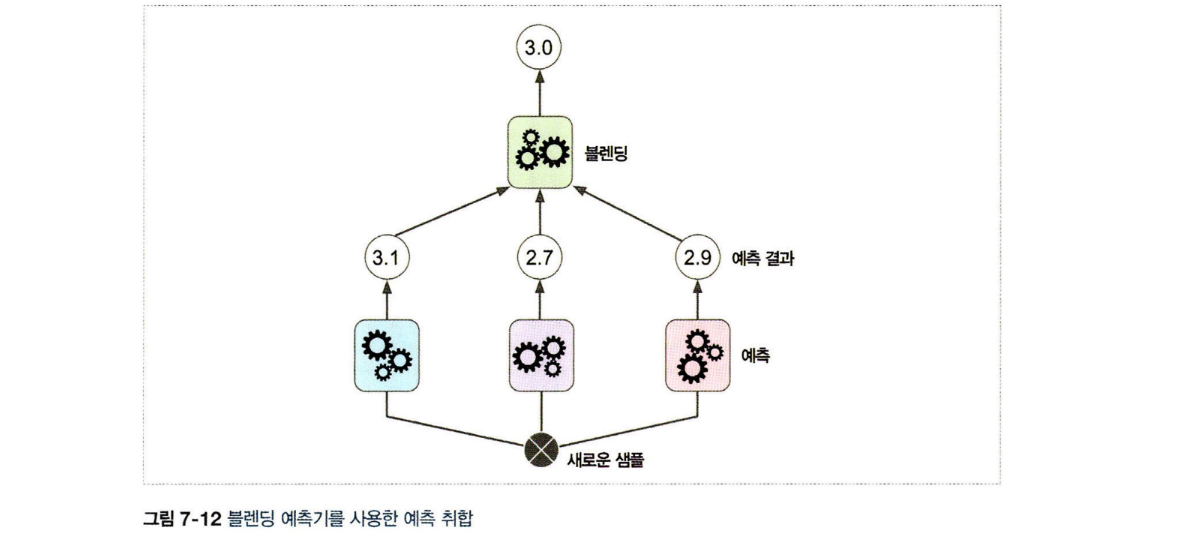

**홀드아웃 세트 사용**
- 블렌더(메타 학습기)를 학습시키는 방법